In [1]:
import os
import matplotlib.image as mpimg
import numpy as np
from skimage.transform import resize

base="datasets/OX Dataset/Train"
classes=['o','x']

images=[]
labels=[]

for cls in classes:
    folder=os.path.join(base,cls)   #"base+O or X"
    for fname in os.listdir(folder):
        if not fname.lower().endswith((".png", ".jpg")):
            continue
        path=os.path.join(folder,fname)
        img=mpimg.imread(path)
        images.append(resize(img,(128,128,3)))
        labels.append(cls)

images=np.array(images)


In [3]:
def center_crop_square(img):
    """이미지 중앙을 정사각형으로 잘라냄"""
    h, w = img.shape[:2]
    side = min(h, w)              # 짧은 변 기준
    top  = (h - side) // 2
    left = (w - side) // 2
    return img[top:top+side, left:left+side]

def load_test_folder(base, classes=("o", "x"), size=128):
    images, labels = [], []
    for cls in classes:
        folder = os.path.join(base, cls)
        for fname in os.listdir(folder):
            if not fname.lower().endswith((".png", ".jpg")):
                continue
            img = mpimg.imread(os.path.join(folder, fname))
            img = center_crop_square(img)   # 중앙 정사각형 크롭
            img = resize(img, (size, size, 3))  # 리사이즈(0~1 정규화 겸함)
            images.append(img)
            labels.append(cls)
    return np.array(images), np.array(labels)

X_test_img, y_test_labels = load_test_folder("datasets/OX Dataset/Test", size=128)

In [5]:
from sklearn.preprocessing import LabelEncoder

encoder=LabelEncoder()

encoder.fit(labels)
labels_encoded=encoder.transform(labels)
labels_encoded[13:20],encoder.classes_

(array([0, 0, 0, 0, 0, 0, 0]), array(['o', 'x'], dtype='<U1'))

In [27]:
from tensorflow.keras import layers, models

data_augmentation = models.Sequential([
    layers.RandomRotation(0.04),          # ±약 15도 회전
    layers.RandomTranslation(0.2, 0.2),   # 상하좌우 10% 이동
    layers.RandomZoom(0.1),               # ±10% 확대축소
], name="augment")

model=models.Sequential([
    layers.Conv2D(32, kernel_size=(3,3), activation='relu',
            input_shape=(128, 128, 3)),
    data_augmentation,
    layers.MaxPooling2D(pool_size=(2,2), strides=(2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.25),
    layers.Dense(2, activation='softmax')
])

/home/ane/tensorflow/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augment (Sequential)            │ (None, 126, 126, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 31, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 31, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 31, 31, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     7,373,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,430,658 (28.35 MB)

 Trainable params: 7,430,658 (28.35 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
X_train = images
y_train = labels_encoded

import time
start_time=time.time()
hist=model.fit(X_train,y_train,validation_split=0.2,epochs=100,verbose=1)
print("fit time: ",time.time()-start_time)


Epoch 1/100


1/3 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.4688 - loss: 0.7758

E0000 00:00:1783664769.892321   78253 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_3_1/dropout_12_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 111ms/step - accuracy: 0.5694 - loss: 5.4356 - val_accuracy: 1.0000 - val_loss: 0.3504
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.4722 - loss: 1.5471 - val_accuracy: 0.0000e+00 - val_loss: 0.7799
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6250 - loss: 0.6853 - val_accuracy: 0.0000e+00 - val_loss: 0.7399
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6250 - loss: 0.6597 - val_accuracy: 0.0000e+00 - val_loss: 0.7112
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.6250 - loss: 0.6727 - val_accuracy: 0.0000e+00 - val_loss: 0.7216
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6250 - loss: 0.6744 - val_accuracy: 0.0000e+00 - val_loss: 0.7554
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6250 - loss: 0.6649 - val_accuracy: 0.0000e+00 - val_loss: 0.8604
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6250 - loss: 0.6813 - val_accuracy: 0.000

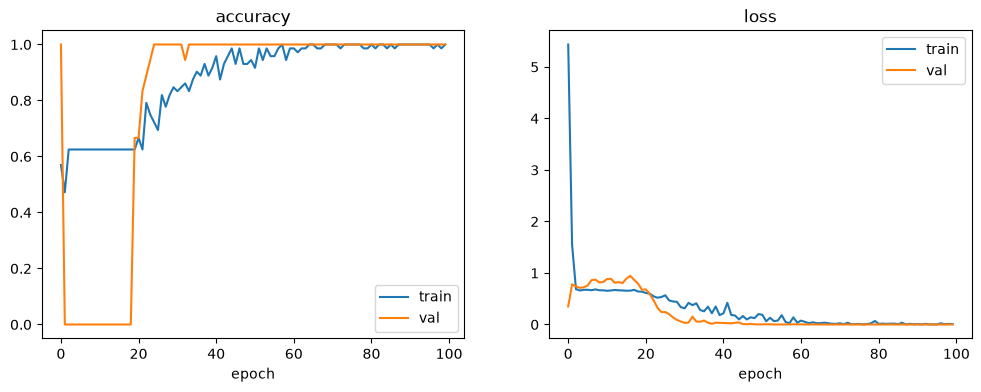

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(hist.history['accuracy'], label='train')
ax1.plot(hist.history['val_accuracy'], label='val')
ax1.set_title('accuracy'); ax1.set_xlabel('epoch'); ax1.legend()

ax2.plot(hist.history['loss'], label='train')
ax2.plot(hist.history['val_loss'], label='val')
ax2.set_title('loss'); ax2.set_xlabel('epoch'); ax2.legend()

plt.show()


In [31]:
y_test=encoder.transform(y_test_labels)
X_test=X_test_img
model.evaluate(X_test,y_test)
pred = model.predict(X_test_img)
print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7000 - loss: 0.6926

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.7000 - loss: 0.6926
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
[[9.9499500e-01 5.0050197e-03]
 [9.4173688e-01 5.8263052e-02]
 [9.8386902e-01 1.6130934e-02]
 [9.9151105e-01 8.4889829e-03]
 [9.6935064e-01 3.0649411e-02]
 [9.8186803e-01 1.8132012e-02]
 [9.3561685e-01 6.4383104e-02]
 [9.9428093e-01 5.7190154e-03]
 [9.3714458e-01 6.2855408e-02]
 [9.3822849e-01 6.1771557e-02]
 [9.5327765e-01 4.6722349e-02]
 [9.3022937e-11 1.0000000e+00]
 [4.6603093e-03 9.9533963e-01]
 [3.1911054e-06 9.9999678e-01]
 [5.2486491e-01 4.7513512e-01]
 [9.3746358e-01 6.2536411e-02]
 [5.4698383e-08 1.0000000e+00]
 [9.4347662e-01 5.6523360e-02]
 [7.0320922e-01 2.9679078e-01]
 [9.4155210e-01 5.8447886e-02]]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
6개 틀림: [10 14 15 17 18 19]


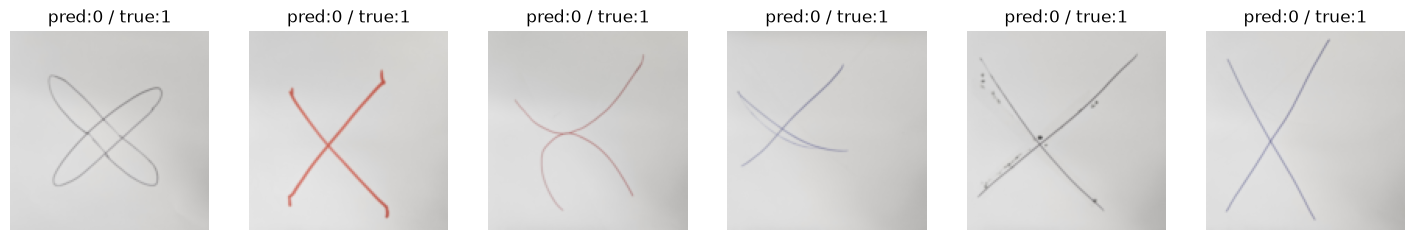

In [ ]:
pred = model.predict(X_test_img)
y_pred = np.argmax(pred, axis=1)          # softmax(2개)인 경우
# sigmoid(1개)면: y_pred = (pred > 0.5).astype(int).flatten()

wrong = np.where(y_pred != y_test)[0]     # 틀린 인덱스만 추출
print(f"{len(wrong)}개 틀림:", wrong)

n = len(wrong)
fig, axes = plt.subplots(1, n, figsize=(3*n, 3))
if n == 1: axes = [axes]
for ax, idx in zip(axes, wrong):
    ax.imshow(X_test_img[idx])
    ax.set_title(f"pred:{y_pred[idx]} / true:{y_test[idx]}")
    ax.axis("off")
plt.show()


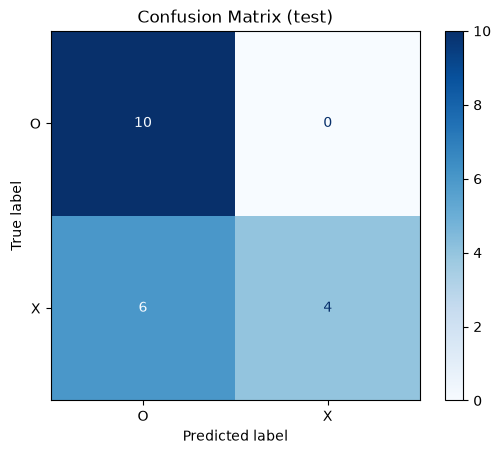

In [33]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["O", "X"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix (test)")
plt.show()